# Noches tropicales en Galicia (1980–2024)

**Fuente de datos:** ERA5-Land — European Centre for Medium-Range Weather Forecasts (ECMWF) / Copernicus Climate Data Store  
**Variable:** Temperatura a las 06:00h como proxy de temperatura mínima nocturna  
**Periodo:** 1980–2024, meses de verano (junio–septiembre)  
**Ciudades:** A Coruña, Vigo, Ourense, Santiago de Compostela, Lugo  

Este notebook parte del fichero `datos/temperaturas_verano_completo.csv` ya procesado.  
Para ver cómo se descargaron y procesaron los datos brutos, consulta `01_descarga_datos.ipynb`.

## 0. Configuración de entorno

In [ ]:
import os
import sys

# Detectar si estamos en Google Colab o en local
EN_COLAB = 'google.colab' in sys.modules

if EN_COLAB:
    # Si estamos en Colab montamos Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA_BASE = '/content/drive/MyDrive/Colab_Notebooks/portfolio_clima/'
else:
    # Si estamos en local usamos ruta relativa al notebook
    RUTA_BASE = '../'

print(f"Entorno: {'Google Colab' if EN_COLAB else 'Local'}")
print(f"Ruta base: {RUTA_BASE}")

Mounted at /content/drive
Entorno: Google Colab
Ruta base: /content/drive/MyDrive/Colab_Notebooks/portfolio_clima/


In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Configuración de estilo para los gráficos
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Colores por ciudad
COLORES = {
    'A Coruña': '#2166ac',
    'Vigo':     '#d73027',
    'Ourense':  '#4dac26',
    'Santiago': '#7b3294',
    'Lugo':     '#e6820a'
}

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga y exploración inicial de datos

In [ ]:
# Cargar el CSV con las series temporales de temperatura
ruta_csv = RUTA_BASE + 'datos/temperaturas_verano_completo.csv'
df = pd.read_csv(ruta_csv, index_col='fecha', parse_dates=True)

# Información básica del dataset
print(f"Periodo: {df.index[0].date()} → {df.index[-1].date()}")
print(f"Días totales: {len(df)}")
print(f"Ciudades: {list(df.columns)}")
print(f"Valores nulos: {df.isna().sum().sum()}")
print("\nPrimeras filas:")
print(df.head(10).round(1))

Periodo: 1980-06-01 → 2024-09-30
Días totales: 5490
Ciudades: ['A Coruña', 'Vigo', 'Ourense', 'Santiago', 'Lugo']
Valores nulos: 0

Primeras filas:
                     A Coruña  Vigo  Ourense  Santiago  Lugo
fecha                                                       
1980-06-01 06:00:00       9.1   9.9      7.5       7.6   7.8
1980-06-02 06:00:00      10.7  10.9      4.9       9.6   7.5
1980-06-03 06:00:00      17.1  14.7     11.5      13.8  12.3
1980-06-04 06:00:00      16.7  15.4     16.9      15.8  15.0
1980-06-05 06:00:00      13.4  14.5     13.2      12.8  12.6
1980-06-06 06:00:00      12.2  11.7      8.8      10.5   8.7
1980-06-07 06:00:00      11.5  11.7      8.8      10.1   8.8
1980-06-08 06:00:00      10.5  10.1      7.3       8.1   5.7
1980-06-09 06:00:00      14.5  14.7     13.0      14.2  12.1
1980-06-10 06:00:00      12.5  12.8     10.4      11.3   9.7


In [ ]:
# Estadísticas descriptivas por ciudad
print("Estadísticas de temperatura a las 06:00h (°C):")
print(df.describe().round(1))

Estadísticas de temperatura a las 06:00h (°C):
       A Coruña    Vigo  Ourense  Santiago    Lugo
count    5490.0  5490.0   5490.0    5490.0  5490.0
mean       15.1    15.1     13.5      13.8    12.8
std         2.0     2.1      2.8       2.3     2.5
min         7.9     6.2      2.7       2.9     2.6
25%        13.8    13.7     11.6      12.2    11.1
50%        15.2    15.2     13.6      14.0    12.9
75%        16.5    16.5     15.5      15.4    14.6
max        26.5    24.2     23.4      26.8    22.4


## 2. Climatología mensual

Temperatura media de cada mes calculada sobre todo el periodo 1980–2024.  
Permite comparar el comportamiento climático típico de cada ciudad.

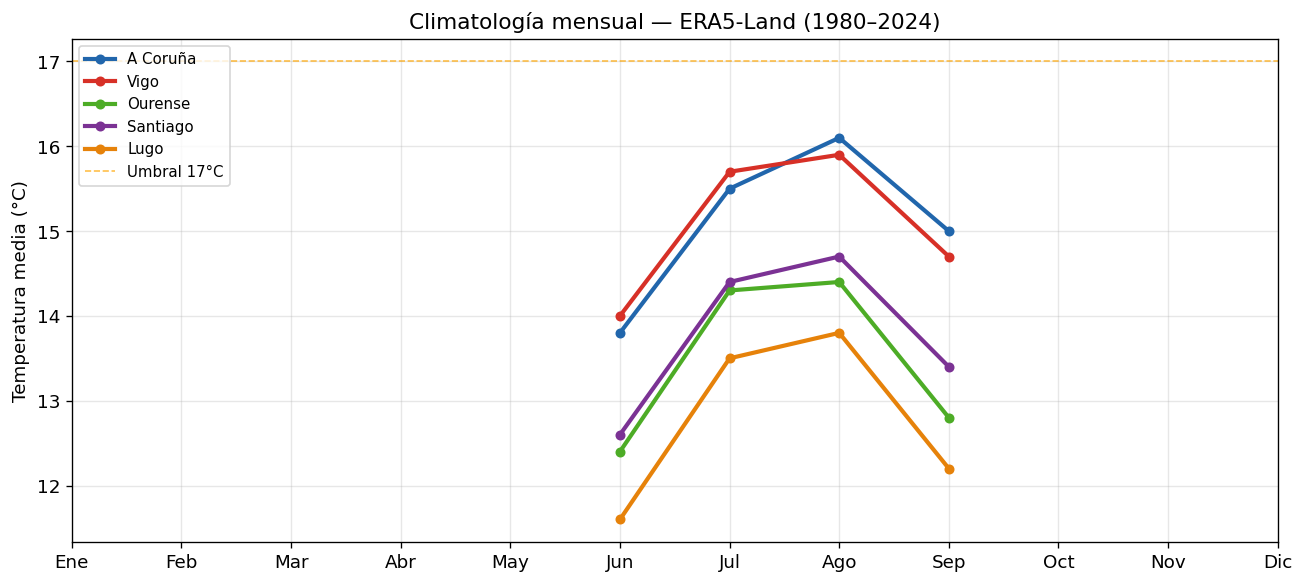

Gráfico guardado


In [ ]:
# Calcular la temperatura media por mes sobre todos los años
df['mes'] = df.index.month
climatologia = df.groupby('mes')[list(COLORES.keys())].mean().round(1)

fig, ax = plt.subplots(figsize=(11, 5))

for ciudad, color in COLORES.items():
    if ciudad in climatologia.columns:
        ax.plot(climatologia.index, climatologia[ciudad],
                color=color, linewidth=2.5, marker='o', markersize=5, label=ciudad)

# Línea de umbral
ax.axhline(y=17, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Umbral 17°C')

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.set_ylabel('Temperatura media (°C)')
ax.set_title('Climatología mensual — ERA5-Land (1980–2024)', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RUTA_BASE + 'graficos/climatologia_mensual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

## 3. Distribución de temperaturas

Histograma de frecuencia de temperaturas nocturnas durante los meses de verano.  
Muestra qué proporción de días supera el umbral de 17°C en cada ciudad.

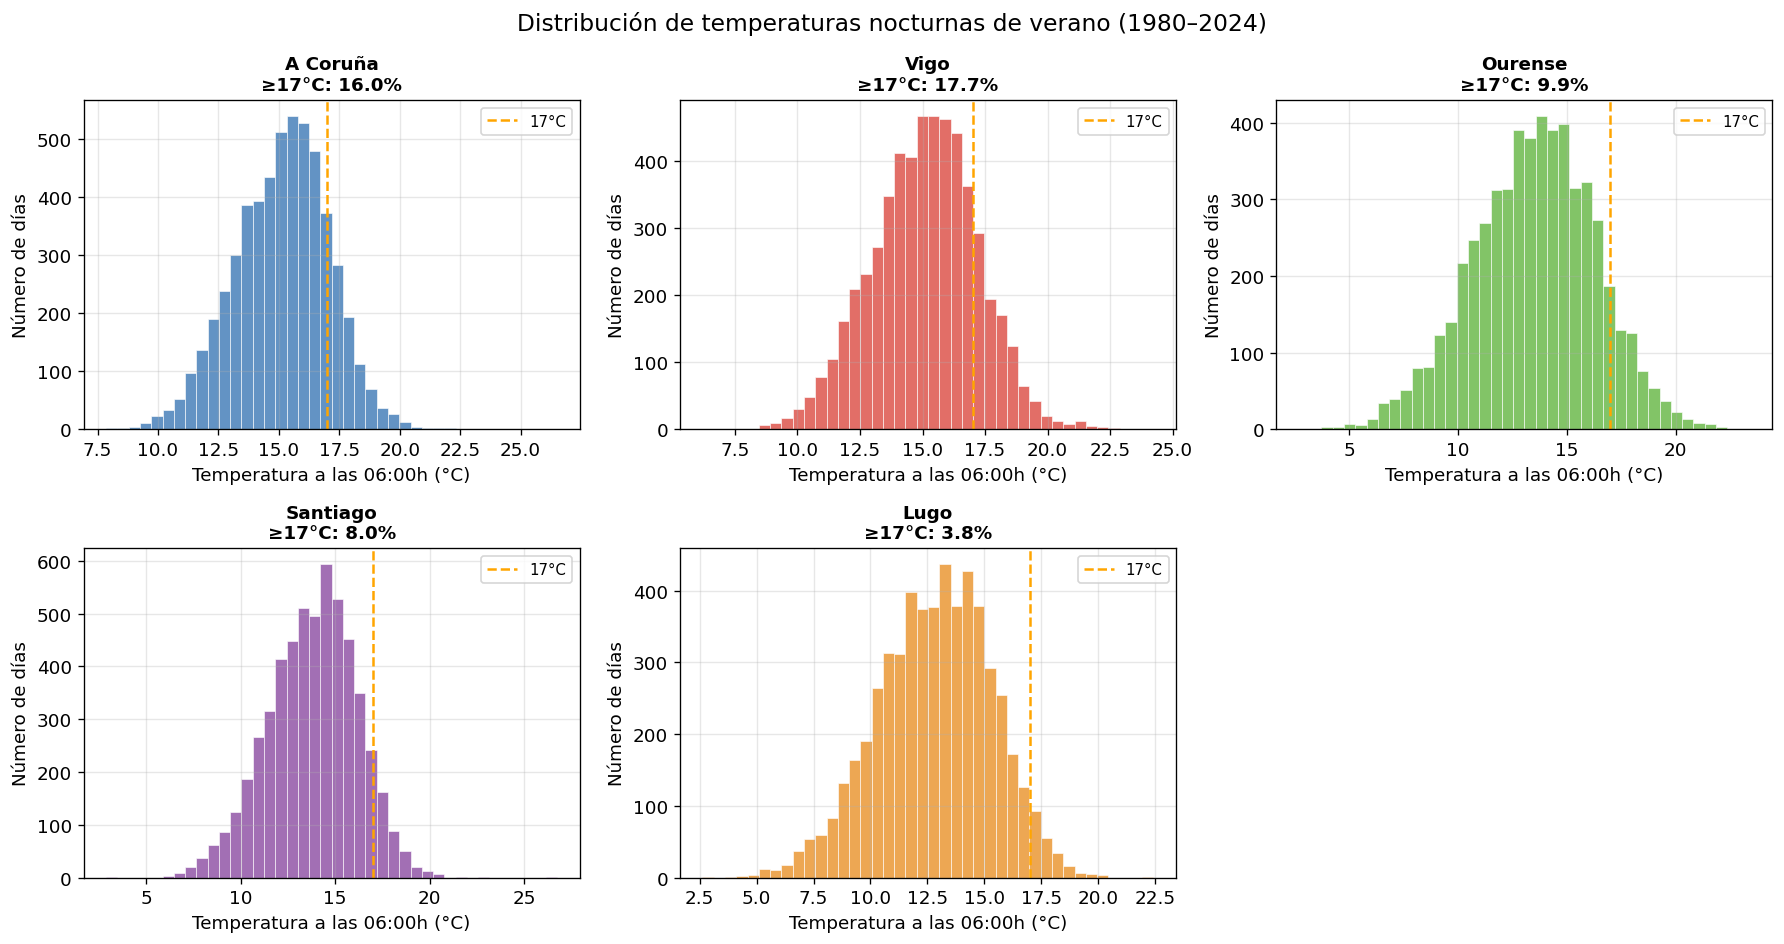

Gráfico guardado


In [ ]:
ciudades = [c for c in COLORES.keys() if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, ciudad in enumerate(ciudades):
    ax = axes[i]

    # Histograma de frecuencia de temperaturas
    ax.hist(df[ciudad].dropna(), bins=40,
            color=COLORES[ciudad], alpha=0.7, edgecolor='white', linewidth=0.5)

    # Líneas de umbral
    ax.axvline(x=17, color='orange', linestyle='--', linewidth=1.5, label='17°C')


    # Porcentaje de días sobre cada umbral
    pct_17 = (df[ciudad] >= 17).mean() * 100
    ax.set_title(f'{ciudad}\n≥17°C: {pct_17:.1f}%',
                 fontsize=11, fontweight='bold')

    ax.set_xlabel('Temperatura a las 06:00h (°C)')
    ax.set_ylabel('Número de días')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Ocultar panel sobrante si hay menos de 6 ciudades
for j in range(len(ciudades), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de temperaturas nocturnas de verano (1980–2024)', fontsize=14)
plt.tight_layout()
plt.savefig(RUTA_BASE + 'graficos/distribucion_temperaturas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

## 4. Indicador de noches cálidas por año

Número de días por año con temperatura a las 06:00h ≥ 17°C.  
Se incluye una regresión lineal para evaluar si la tendencia es estadísticamente significativa.

In [ ]:
# Añadir columna de año
df['año'] = df.index.year

# Calcular días por año con temperatura >= 17°C
noches = df.groupby('año')[ciudades].apply(lambda x: (x >= 17).sum())

print("Días con temperatura ≥ 17°C a las 06:00h por año:")
print(noches.to_string())

Días con temperatura ≥ 17°C a las 06:00h por año:
      A Coruña  Vigo  Ourense  Santiago  Lugo
año                                          
1980        13    11        5         7     3
1981        11    17        6         7     2
1982         2     9        6         1     1
1983        17    10        7         4     1
1984         6    11        3         4     1
1985        10    18       11         7     2
1986        13    18        9         5     2
1987        25    39       25        15     8
1988         7    12        7         5     3
1989        28    33       19        15     4
1990        27    34       20        17    10
1991        28    36       14        13     2
1992        18    17       15        11     7
1993        10    15        7         5     2
1994        15     9        6         7     1
1995        24    23        9         6     3
1996         7    11        8         3     3
1997        20    19       10         7     5
1998        23    28       17 

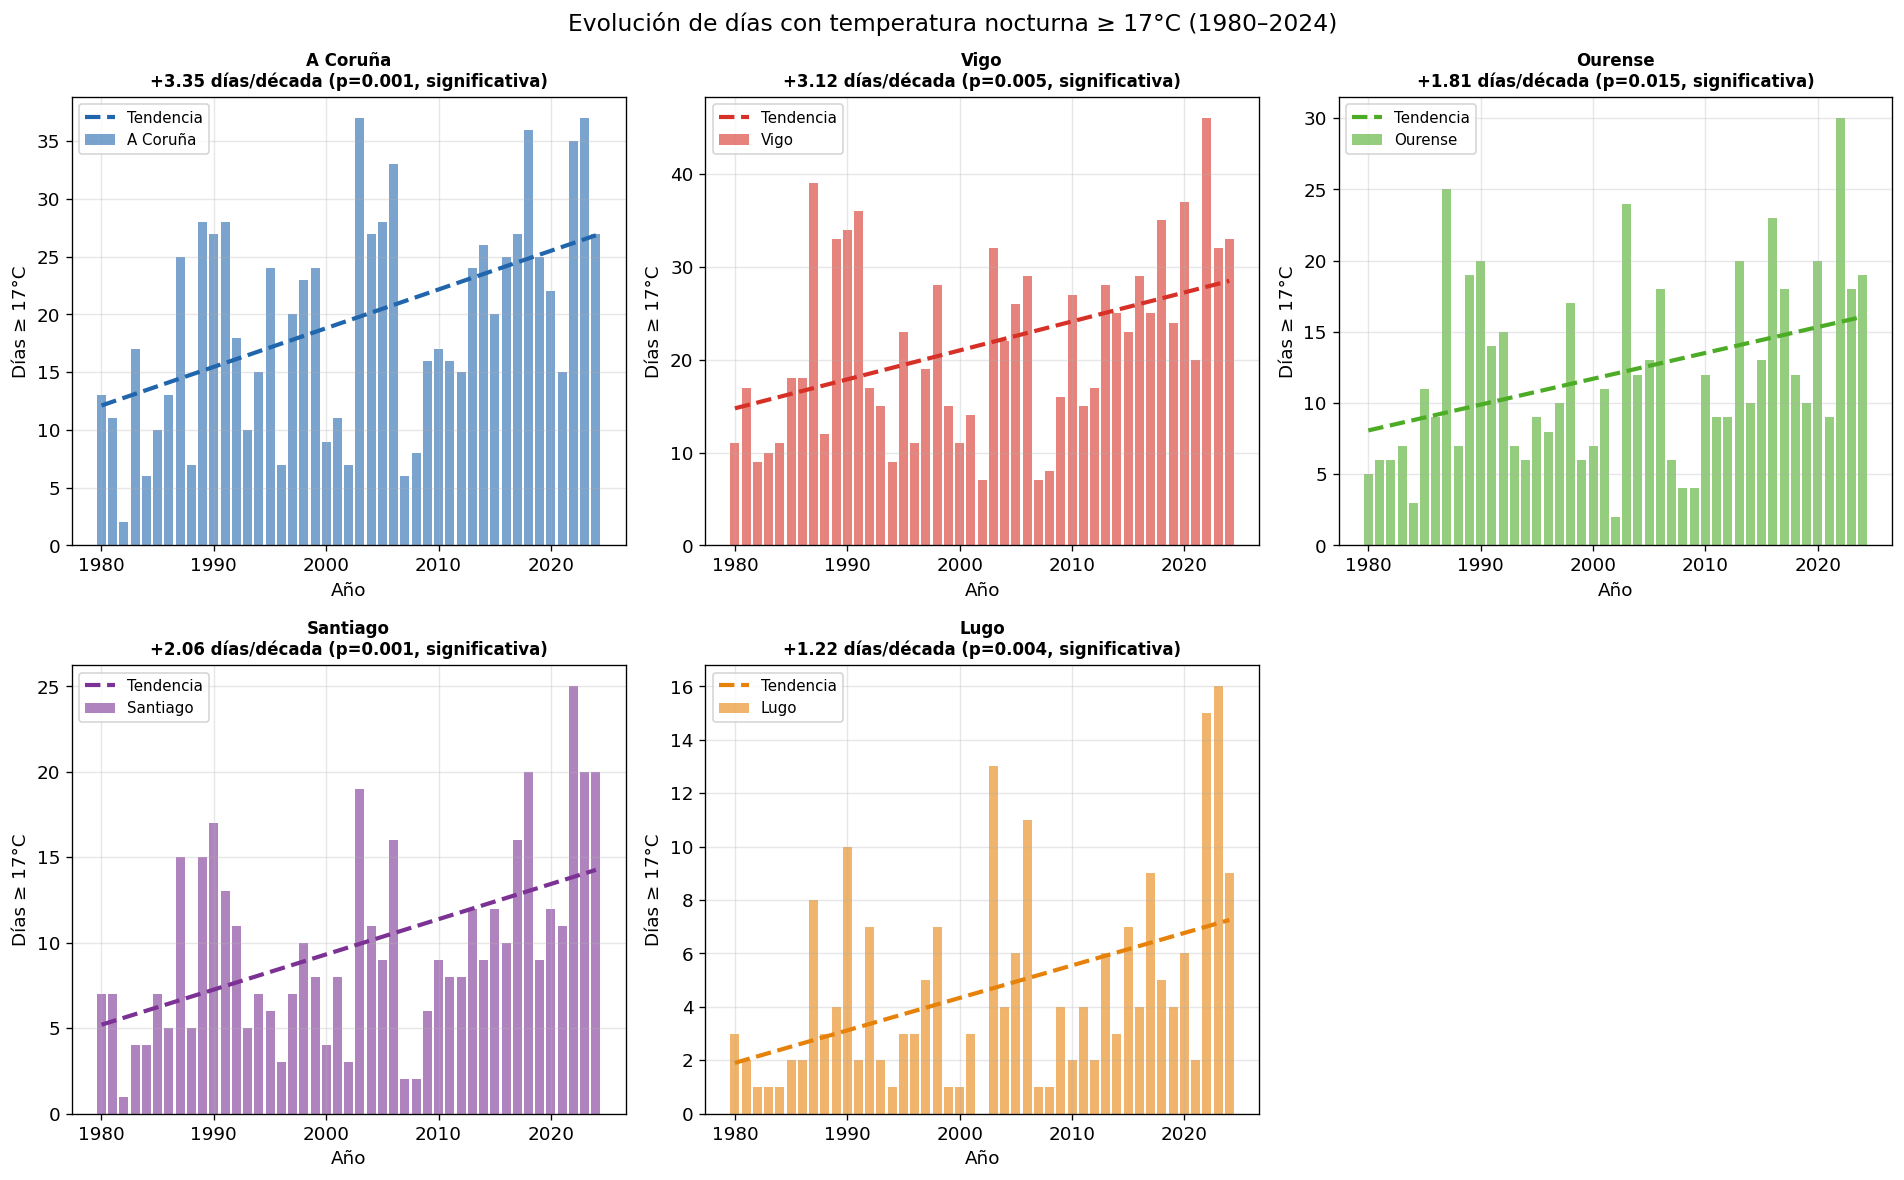

Gráfico guardado


In [ ]:
# Gráfico de tendencias por ciudad con regresión lineal
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

resultados = {}

for i, ciudad in enumerate(ciudades):
    ax = axes[i]

    # Barras por año
    ax.bar(noches.index, noches[ciudad],
           color=COLORES[ciudad], alpha=0.6, label=ciudad)

    # Regresión lineal para calcular la tendencia
    x = noches.index.values
    y = noches[ciudad].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    tendencia = slope * x + intercept
    resultados[ciudad] = {'slope': slope, 'p_value': p_value, 'r2': r_value**2}

    # Línea de tendencia
    ax.plot(x, tendencia, color=COLORES[ciudad],
            linewidth=2.5, linestyle='--', label='Tendencia')

    # Indicar si la tendencia es estadísticamente significativa
    sig = 'significativa' if p_value < 0.05 else 'no significativa'
    ax.set_title(f'{ciudad}\n+{slope*10:.2f} días/década (p={p_value:.3f}, {sig})',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Días ≥ 17°C')
    ax.set_xlabel('Año')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Ocultar panel sobrante
for j in range(len(ciudades), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Evolución de días con temperatura nocturna ≥ 17°C (1980–2024)', fontsize=14)
plt.tight_layout()
plt.savefig(RUTA_BASE + 'graficos/noches_tropicales_tendencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

In [ ]:
# Tabla resumen de resultados estadísticos
print("Resumen de tendencias:")
print(f"{'Ciudad':<12} {'Días/década':>12} {'p-valor':>10} {'Significativa':>14}")
print("-" * 52)
for ciudad, res in resultados.items():
    sig = 'Sí' if res['p_value'] < 0.05 else 'No'
    print(f"{ciudad:<12} {res['slope']*10:>+12.2f} {res['p_value']:>10.3f} {sig:>14}")

Resumen de tendencias:
Ciudad        Días/década    p-valor  Significativa
----------------------------------------------------
A Coruña            +3.35      0.001             Sí
Vigo                +3.12      0.005             Sí
Ourense             +1.81      0.015             Sí
Santiago            +2.06      0.001             Sí
Lugo                +1.22      0.004             Sí


## 5. Comparativa entre ciudades

Evolución temporal con media móvil de 5 años para comparar el comportamiento de todas las ciudades en un solo panel.

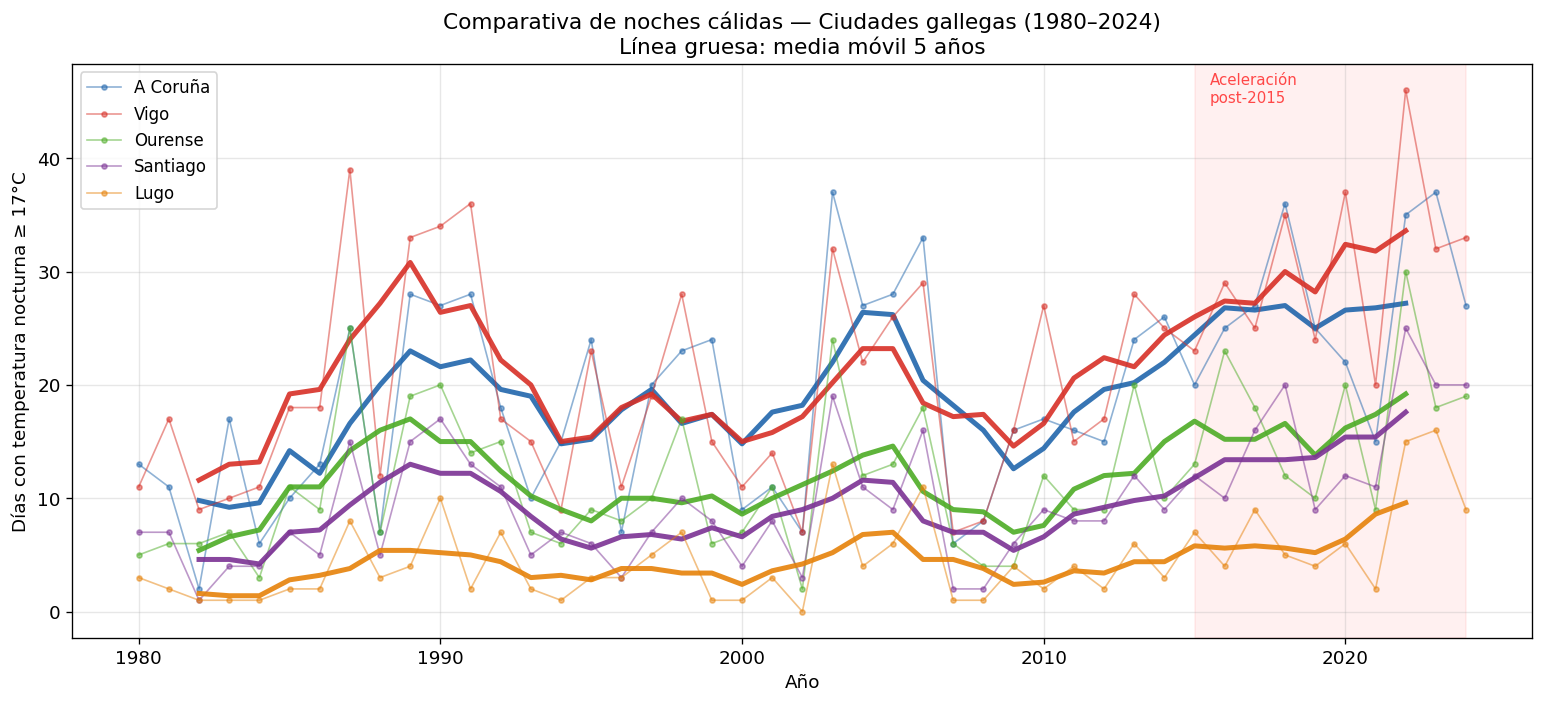

Gráfico guardado


In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

for ciudad in ciudades:
    color = COLORES[ciudad]

    # Serie anual con línea fina
    ax.plot(noches.index, noches[ciudad],
            color=color, linewidth=1, marker='o', markersize=3, alpha=0.5, label=ciudad)

    # Media móvil de 5 años encima para ver la tendencia
    media_movil = noches[ciudad].rolling(window=5, center=True).mean()
    ax.plot(noches.index, media_movil,
            color=color, linewidth=3, alpha=0.9)

# Sombrear periodo de aceleración post-2015
ax.axvspan(2015, noches.index[-1], alpha=0.06, color='red')
ax.text(2015.5, ax.get_ylim()[1] * 0.93, 'Aceleración\npost-2015',
        fontsize=9, color='red', alpha=0.7)

ax.set_ylabel('Días con temperatura nocturna ≥ 17°C')
ax.set_xlabel('Año')
ax.set_title('Comparativa de noches cálidas — Ciudades gallegas (1980–2024)\nLínea gruesa: media móvil 5 años',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RUTA_BASE + 'graficos/comparativa_ciudades.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

## 6. Anomalías térmicas

Desviación de cada año respecto a la media histórica 1980–2024.  
Este es el formato estándar utilizado por organismos como la AEMET para comunicar el cambio climático.

In [ ]:
# Calcular la media histórica de todo el periodo
media_historica = noches[ciudades].mean()

# Calcular la anomalía de cada año respecto a esa media
anomalias = noches[ciudades] - media_historica

print("Media histórica de días ≥ 17°C por ciudad:")
print(media_historica.round(1))

Media histórica de días ≥ 17°C por ciudad:
A Coruña    19.5
Vigo        21.6
Ourense     12.1
Santiago     9.7
Lugo         4.6
dtype: float64


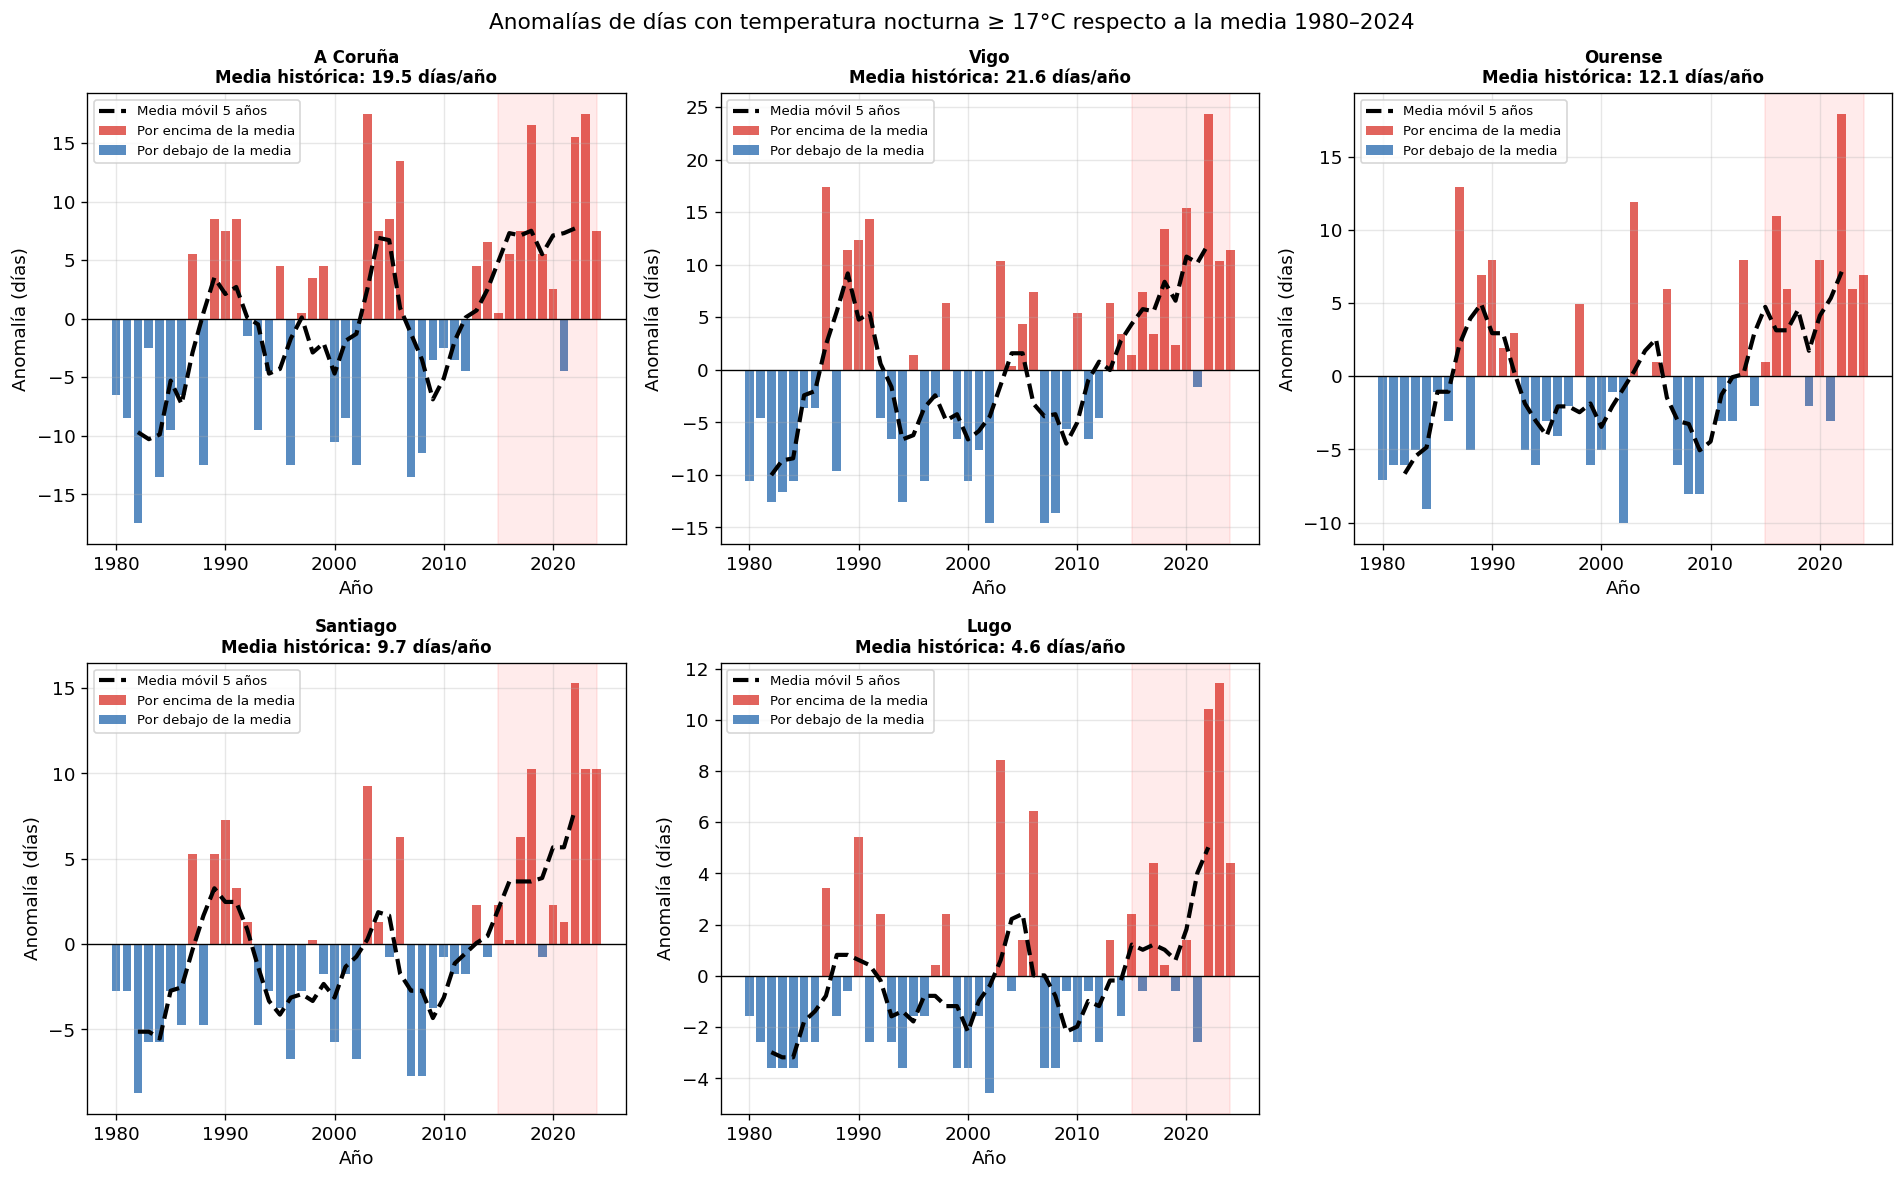

Gráfico guardado


In [ ]:
# Gráfico de anomalías por ciudad
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, ciudad in enumerate(ciudades):
    ax = axes[i]
    valores = anomalias[ciudad]
    años = anomalias.index

    # Barras rojas para años más cálidos de lo normal
    ax.bar(años[valores >= 0], valores[valores >= 0],
           color='#d73027', alpha=0.75, label='Por encima de la media')

    # Barras azules para años más fríos de lo normal
    ax.bar(años[valores < 0], valores[valores < 0],
           color='#2166ac', alpha=0.75, label='Por debajo de la media')

    # Línea de cero (media histórica)
    ax.axhline(y=0, color='black', linewidth=0.8)

    # Media móvil de 5 años
    media_movil = valores.rolling(window=5, center=True).mean()
    ax.plot(años, media_movil, color='black', linewidth=2.5,
            linestyle='--', label='Media móvil 5 años')

    # Sombrear periodo post-2015
    ax.axvspan(2015, años[-1], alpha=0.08, color='red')

    ax.set_title(f'{ciudad}\nMedia histórica: {media_historica[ciudad]:.1f} días/año',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Anomalía (días)')
    ax.set_xlabel('Año')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Ocultar panel sobrante
for j in range(len(ciudades), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Anomalías de días con temperatura nocturna ≥ 17°C respecto a la media 1980–2024',
             fontsize=13)
plt.tight_layout()
plt.savefig(RUTA_BASE + 'graficos/anomalias_termicas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

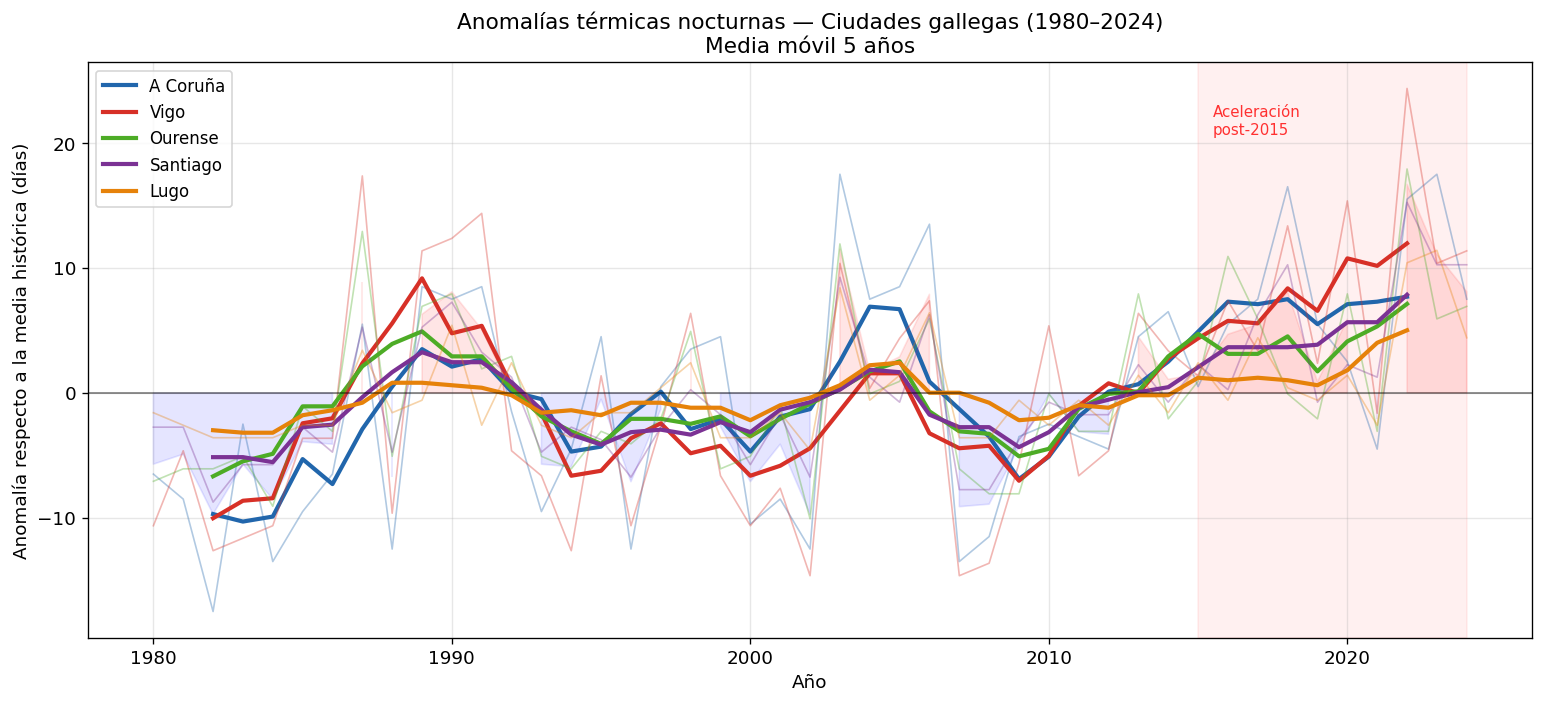

Gráfico guardado


In [ ]:
# Gráfico comparativo de anomalías — todas las ciudades en un panel
fig, ax = plt.subplots(figsize=(13, 6))

for ciudad in ciudades:
    color = COLORES[ciudad]

    # Serie anual con transparencia
    ax.plot(anomalias.index, anomalias[ciudad],
            color=color, linewidth=1, alpha=0.35)

    # Media móvil de 5 años
    media_movil = anomalias[ciudad].rolling(window=5, center=True).mean()
    ax.plot(anomalias.index, media_movil,
            color=color, linewidth=2.5, label=ciudad)

# Línea de cero
ax.axhline(y=0, color='black', linewidth=1, alpha=0.5)

# Sombrear zonas positiva y negativa de la media de todas las ciudades
media_global = anomalias[ciudades].mean(axis=1)
ax.fill_between(anomalias.index, 0, media_global,
                where=media_global >= 0, alpha=0.1, color='red')
ax.fill_between(anomalias.index, 0, media_global,
                where=media_global < 0,  alpha=0.1, color='blue')

# Etiqueta de aceleración post-2015
ax.axvspan(2015, anomalias.index[-1], alpha=0.06, color='red')
ymax = anomalias[ciudades].max().max()
ax.text(2015.5, ymax * 0.85, 'Aceleración\npost-2015',
        fontsize=9, color='red', alpha=0.8)

ax.set_ylabel('Anomalía respecto a la media histórica (días)')
ax.set_xlabel('Año')
ax.set_title('Anomalías térmicas nocturnas — Ciudades gallegas (1980–2024)\nMedia móvil 5 años',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RUTA_BASE + 'graficos/anomalias_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

## 7. Conclusiones

### Resultados principales

El análisis de las series temporales ERA5-Land para los meses de verano (junio–septiembre) en cinco ciudades gallegas durante el periodo 1980–2024 muestran un **aumento estadísticamente significativo** (p < 0.05) en el número de días de verano con temperatura nocturna superior a 17ºC.


| Ciudad | Incremento | p-valor | Significativa |
|--------|-----------|---------|---------------|
| A Coruña | +3.35 días/década | 0.001 | Sí |
| Vigo | +3.12 días/década | 0.005 | Sí |
| Santiago | +2.06 días/década | 0.001 | Sí |
| Ourense | +1.81 días/década | 0.015 | Sí |

### Interpretación

El análisis de anomalías revela tres fases diferenciadas:
- 1980–1994 — Periodo de referencia fresco. Las cinco ciudades se mantienen sistemáticamente por debajo de su media histórica. Las noches cálidas son eventos aislados sin patrón claro.
- 1995–2014 — Periodo de oscilación. Aparece la primera señal de calentamiento en los años 90 seguida de una moderación en la primera década del siglo XXI, consistente con la variabilidad de la Oscilación Multidecadal del Atlántico Norte (AMO) documentada en la literatura.
- 2015–2024 — Periodo de aceleración sostenida. Las cinco ciudades se mantienen por encima de su media histórica durante nueve años consecutivos, algo que no ocurre en ningún otro momento de la serie. Este es el hallazgo más robusto del análisis: no son años extremos aislados sino una nueva línea de base más cálida.


### Limitaciones

- La temperatura a las 06:00h es una aproximación de la mínima nocturna, no el valor exacto.En días con frentes cálidos nocturnos el mínimo real puede ocurrir antes de esa hora, lo que introduce una subestimación sistemática del número de eventos reales.
- La resolución espacial de 9 km de ERA5-Land no captura microclimas urbanos ni el efecto isla de calor a escala de barrio.Los valores reales en los centros urbanos más densos probablemente son más altos que los aquí reportados.
- 9 años de tendencia post-2015 son insuficientes para establecer un cambio de régimen definitivo.En climatología el estándar para hablar de cambio de período de referencia son 30 años. Lo que sí podemos afirmar es que el periodo 2015–2024 es estadísticamente anómalo respecto a los 35 años anteriores.

### Implicaciones para la planificación urbana
Los resultados tienen aplicación directa en tres ámbitos que son objeto habitual de estudios de impacto ambiental en consultoras:
- En salud pública, el incremento de noches con temperatura elevada afecta especialmente a población mayor y a trabajadores de exterior. A Coruña, con el mayor incremento relativo, ha pasado de unas 13 noches cálidas en 1980 a más de 35 en 2024, lo que multiplica el riesgo de estrés térmico acumulado.
- En planificación urbana y zonas verdes, los resultados justifican la priorización de infraestructura verde en las ciudades con mayor crecimiento de la señal térmica, particularmente en los barrios con menor cobertura vegetal donde el efecto isla de calor amplifica la tendencia detectada a escala regional.
- En eficiencia energética, el aumento de noches cálidas se correlaciona directamente con mayor demanda de climatización nocturna, con implicaciones para la planificación de la red eléctrica y para los estudios de impacto energético de nuevos desarrollos urbanos.

### Líneas de mejora metodológica
Un análisis posterior más robusto debería incorporar datos horarios completos para calcular la temperatura mínima diaria real en lugar del proxy de las 06:00h, datos de estaciones meteorológicas de AEMET para validar los resultados ERA5-Land a escala local, e índices de cobertura vegetal NDVI derivados de Landsat para cruzar la señal térmica con la evolución del uso del suelo urbano.

### Fuente de datos

Hersbach, H. et al. (2020). The ERA5 global reanalysis. *Quarterly Journal of the Royal Meteorological Society*, 146(730), 1999–2049. https://doi.org/10.1002/qj.3803